In [74]:
import numpy as np
import pandas as pd
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
import seaborn as sns
sns.set_style(style="darkgrid")

In [44]:
raw_data = pd.read_csv("anti-malware.csv")

In [45]:
raw_data

,NtDuplicateObject,NtOpenSection,CoUninitialize,RegCloseKey,LdrUnloadDll,DrawTextExW,GetSystemInfo,RegQueryValueExA,getaddrinfo,WSAStartup,...,CreateRemoteThreadEx,NtCreateDirectoryObject,EnumServicesStatusA,NtShutdownSystem,NtCreateProcessEx,NotifyBootConfigStatus,NtSaveKey,system,WNetGetProviderNameW,OUTPUT
0,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,2,0,10,0,4,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,5,2,2,96,2,15,3,116,2,1,...,0,0,0,0,0,0,0,0,0,1
3,9,13,5,662,37,0,0,405,0,1,...,0,0,0,0,0,0,0,0,0,1
4,3,2,2,94,3,17,4,116,2,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11256,204,41,109,2680,77,102,24,148,0,12,...,0,0,0,0,0,0,0,0,0,1
11257,197,39,107,2525,73,135,24,148,0,12,...,0,0,0,0,0,0,0,0,0,1
11258,198,39,109,2534,72,162,22,188,0,11,...,0,0,0,0,0,0,0,0,0,1
11259,13,0,3,481,29,0,101,171,10,5,...,0,0,0,0,0,0,0,0,0,1


In [46]:
attr = list(raw_data.columns.values)

In [47]:
min_max_scaler = MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(raw_data[attr].values)
normal = pd.DataFrame(x_scaled, columns=attr, index=raw_data.index)
raw_data[attr] = normal
raw_data

,NtDuplicateObject,NtOpenSection,CoUninitialize,RegCloseKey,LdrUnloadDll,DrawTextExW,GetSystemInfo,RegQueryValueExA,getaddrinfo,WSAStartup,...,CreateRemoteThreadEx,NtCreateDirectoryObject,EnumServicesStatusA,NtShutdownSystem,NtCreateProcessEx,NotifyBootConfigStatus,NtSaveKey,system,WNetGetProviderNameW,OUTPUT
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000010,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.000004,0.000400,0.000000,0.000019,0.000000,0.000021,0.000019,0.000000,0.000000,0.000125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000011,0.000400,0.000065,0.000184,0.000029,0.000078,0.000057,0.004241,0.006410,0.000125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.000019,0.002601,0.000163,0.001270,0.000534,0.000000,0.000000,0.014809,0.000000,0.000125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.000006,0.000400,0.000065,0.000180,0.000043,0.000089,0.000076,0.004241,0.006410,0.000125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11256,0.000432,0.008202,0.003564,0.005142,0.001112,0.000534,0.000455,0.005412,0.000000,0.001494,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11257,0.000417,0.007802,0.003499,0.004845,0.001054,0.000706,0.000455,0.005412,0.000000,0.001494,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11258,0.000419,0.007802,0.003564,0.004862,0.001040,0.000848,0.000417,0.006874,0.000000,0.001370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11259,0.000028,0.000000,0.000098,0.000923,0.000419,0.000000,0.001914,0.006253,0.032051,0.000623,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [48]:
Y = np.array(raw_data.pop('OUTPUT'))
X = np.array(raw_data)

array([1., 1., 1., ..., 1., 1., 1.], shape=(11261,))

In [52]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2)

In [54]:
X.shape,x_train.shape, x_test.shape

((11261, 311), (9008, 311), (2253, 311))

In [65]:
lg = LogisticRegression()
lg.fit(x_train, y_train)
y_pred = lg.predict(x_test)
lg.score(x_test, y_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [72]:
cm

array([[ 103,  393],
       [  48, 1709]])

<Axes: >

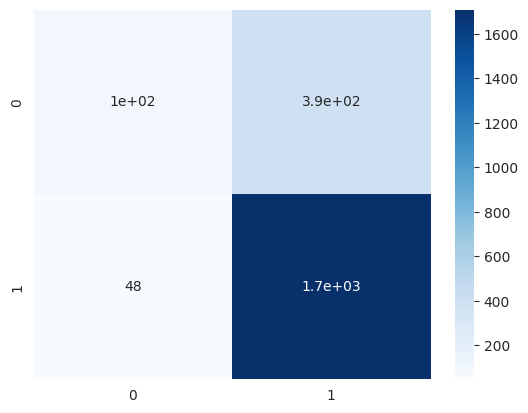

In [73]:
sns.heatmap(cm,annot=True,cmap="Blues")

<Axes: >

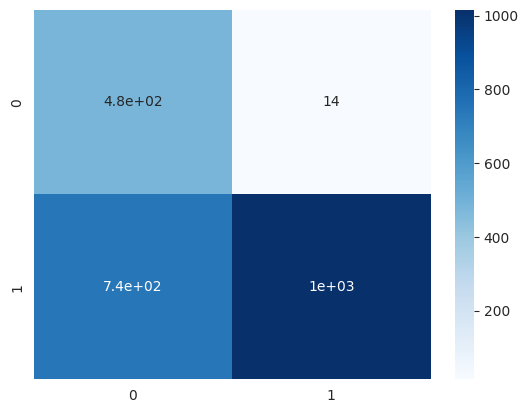

In [86]:
gnb = GaussianNB()

gnb.fit(x_train, y_train)

y_pred = gnb.predict(x_test)
gnb.score(x_test, y_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues")